In [84]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [85]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [86]:
using JLD2
using DataFrames, DataFramesMeta

In [119]:
includet("../../../scripts/figures_util.jl")

In [87]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Get data from all files

In [88]:
for f in files
    close(f)
end
GC.gc()

In [123]:
ks = [0.0, 0.001, 0.01, 0.1, 0.2]
files = map(ks) do k
    jldopen(@sprintf "./wrtk_2/d1_k%.1f.jld2" k)
end;
Ks = files[1]["metadata"].Ks;

In [114]:
ks = [0.08, 0.09, 0.1, 0.11, 0.12]
files = map(ks) do k
    jldopen("./wrtk_4/d1_k$k.jld2")
end;
Ks = files[1]["metadata"].Ks;

In [124]:
full_df = DataFrame(;
    K=Float64[],
    k=Float64[],
    retcode=Any[],
    fT=Any[],
    fs=Any[],
)
for (k, f) in zip(ks, files)
    fKs = f["Ks"]
    results = f["results"]
    for i in 1:length(fKs)
        r = results[i]
        for (rc, fT, fs) in zip(r.retcodes, r.fTs, r.fss)
            push!(full_df, (fKs[i], k, rc, fT, fs))
        end
    end
end
df = @subset(full_df, :fT .== 1e8, :retcode .== ReturnCode.Success);
nrow(df)

1939

In [125]:
# jldsave("./wrtk_4/df.jld2"; df=full_df, metadata=files[1]["metadata"])

# Plotting final states

In [109]:
for i in 1:length(files)
    fig = plot_many_final_states(files[i], 10, 1:2:length(Ks))
    # fig = plot_many_final_states(files[i], 3, 4:4:length(Ks))
    Label(fig[0,:], (@sprintf "This is for k=%.3g (0 is pure competition, 1 is cosmo)." ks[i]); fontsize=30)
    Makie.save("./wrtk_4/fs_$i.pdf", fig)
end

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

# Plotting outcomes

In [126]:
for i in 1:length(files)
    f = files[i]
    fmetadata = f["metadata"]
    Ks = f["Ks"]
    numKs = length(Ks)
    results = f["results"];
    
    
    surv_threshold = 1e-9
    num_ext = zeros(numKs)
    num_coex = zeros(numKs)
    num_S1 = zeros(numKs)
    num_S2 = zeros(numKs)
    num_bad = zeros(numKs)
    for iK in 1:length(Ks)
        for (rc, fT, fs) in zip(results[iK].retcodes, results[iK].fTs, results[iK].fss)
            if (fT == fmetadata.T) && (rc == ReturnCode.Success)
                m1 = mean(@view fs[1,:])
                m2 = mean(@view fs[2,:])
                if (m1 < surv_threshold) && (m2 < surv_threshold)
                    num_ext[iK] += 1
                elseif (m1 < surv_threshold)
                    num_S2[iK] += 1
                elseif (m2 < surv_threshold)
                    num_S1[iK] += 1
                else
                    num_coex[iK] += 1
                end
            else
                num_bad[iK] += 1
            end
        end
    end
    @assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2 .+ num_bad) .== fmetadata.numrepeats)
    
    
    fig = Figure(;)
    ax = Axis(fig[1,1];
        xscale=log10,
        xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
        ylabel=L"\text{Counts}",
    )

    plot_binom_sample!(ax, Ks, num_ext, fmetadata.numrepeats;
        color=PaperColors.extinct1(),
        label="Extinction",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_S1, fmetadata.numrepeats;
        color=PaperColors.twomms_1(),
        label="Only 1",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_S2, fmetadata.numrepeats;
        color=PaperColors.twomms_2(),
        label="Only 2",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_coex, fmetadata.numrepeats;
        color=PaperColors.twomms_coexistence(),
        label="Coexistence",
        sl_kwargs=(; markersize=0.),
    )
    plot_binom_sample!(ax, Ks, num_bad, fmetadata.numrepeats;
        color=:red,
        label="Bad",
    )
    
    Label(fig[0,:], (@sprintf "This is for k=%.3g (0 is pure competition, 1 is cosmo)." ks[i]); fontsize=20)
    Makie.save("./wrtk_2/outcomes_$i.pdf", fig)
end

# Number of survivors

In [100]:
df.num_surv = num_survivors_in_space.(df.fs, 2);

In [101]:
kgroups = @groupby(df, :k);

## Box plots

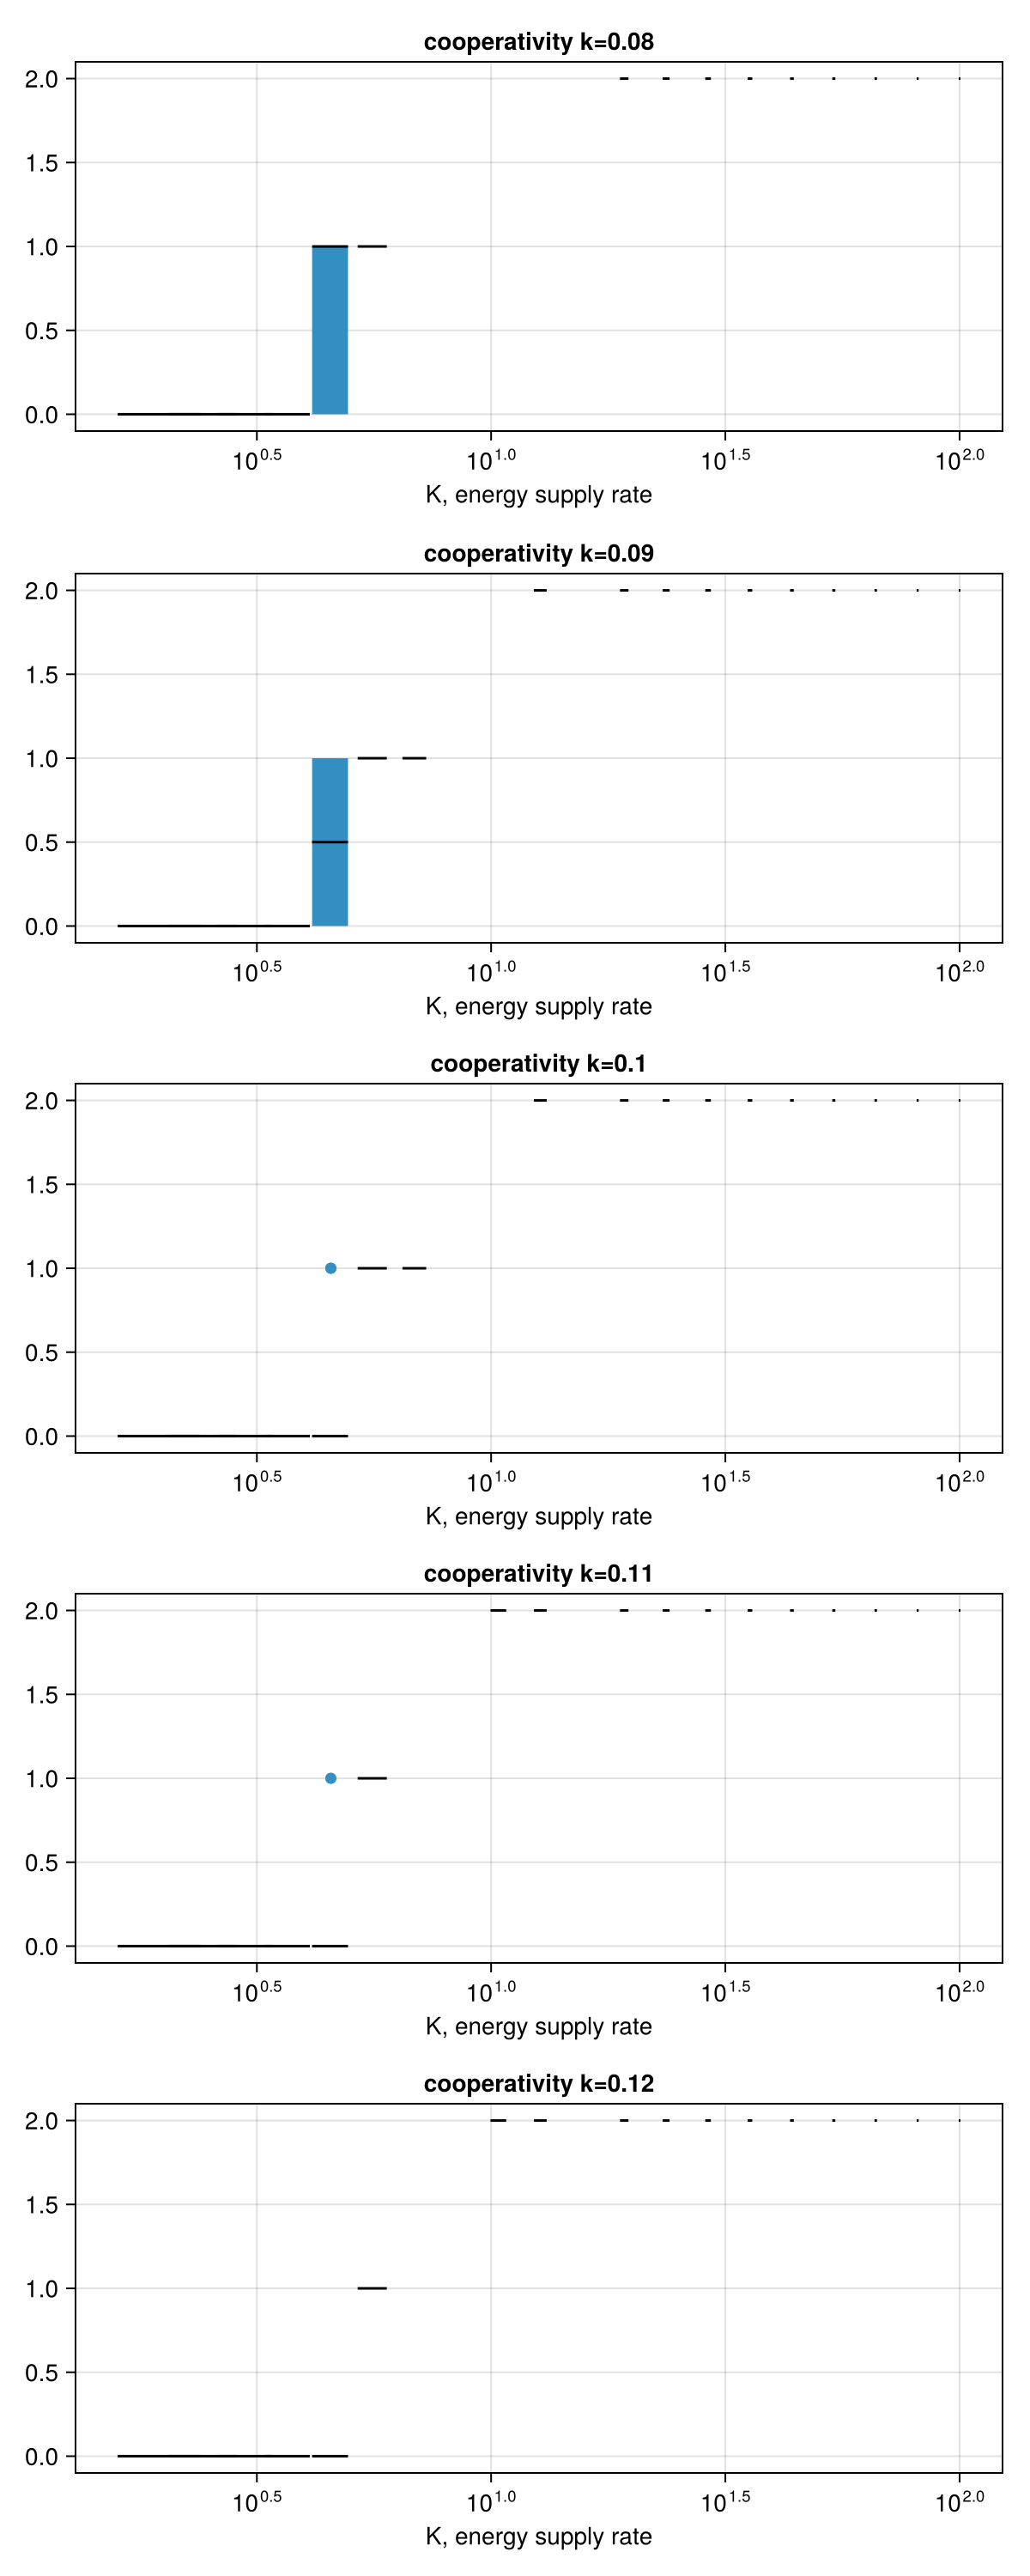

In [103]:
fig = Figure(;
    size=(600, 300 * length(kgroups))
)
for (i, sdf) in enumerate(kgroups)
    ax = Axis(fig[i,1];
        xscale=log10,
        title=(@sprintf "cooperativity k=%.3g" sdf.k[1]),
        xlabel="K, energy supply rate",
    )
    boxplot!(ax, sdf.K, sdf.num_surv)
end
# Makie.save("wrtk_4/num_surv_bp.pdf", fig)
fig